> **📎 EXAMPLE RUN — READ-ONLY ARTIFACT**
>
> This notebook is a **frozen record of a pipeline run** on the bundled example PDB (`example/bound_example.pdb`, an Adalimumab variant with a homotrimeric antigen on chains A/B/C and antibody on chains D/G). It is preserved for reference only — cells are **not** meant to be re-executed here.
>
> The selected rescue mutations reported by this run are **V52S, S108L, T100L** (top-3 non-key-binding positions on chain D by ascending WT unbound logit; Step 5 flagged 6 residues as key-binding and they are automatically skipped).
>
> **To run your own analysis**, use the fresh notebook at `../expression_rescue.ipynb` — it has the same code with outputs cleared.
>
> ---
>
> ⚠️ **Note on the Step 8 3-D views:** GitHub renders notebooks with JavaScript **disabled** for security. The `py3Dmol` cell output relies on the 3Dmol.js library loaded from an external CDN, so here on GitHub you will see an error banner (`3Dmol.js failed to load for some reason`) instead of the interactive structure. **This is a GitHub rendering limitation, not a pipeline problem.** When you open this notebook locally (Jupyter / JupyterLab / VS Code), the 3-D views render normally. The underlying `.pdb` files with B-factor-encoded logits are also saved to `example/example_output/` and the other static outputs (heatmap, CSVs) display correctly here.

# Expression Rescue Pipeline

Given an antibody-antigen bound complex PDB, this notebook proposes single-point mutations in CDR loops that may **rescue antibody expression** without disrupting antigen binding.

**Method.** We run ProteinMPNN single-AA scoring on two states:

- **bound**: the input complex as-is
- **unbound**: the same complex with the antigen chain(s) removed

ProteinMPNN produces per-residue logits over the 21-letter amino acid alphabet conditional on the structural context. Comparing the two states residue-by-residue yields two actionable signals:

| Signal | Definition | Interpretation |
|--------|------------|----------------|
| **Key binding residues** | Positions where the wild-type amino acid has a much higher logit in the bound state than in the unbound state (Δ = logit_bound - logit_unbound > threshold) | The residue is *preferred because of* the antigen contact - changing it would likely cost binding affinity. |
| **Rescue candidates** | Positions where an alternative amino acid has a higher logit in the unbound state than the current wild-type amino acid | The residue is already suboptimal for the monomer alone - a substitution may improve expression/stability without touching the binding interface. |

The notebook runs end-to-end for **one input complex per invocation**. Configure the user-input cell below and run all cells.

In [1]:
import csv
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import py3Dmol
import seaborn as sns
import torch

from prody import parsePDB, writePDB

/home/fullmoon/.conda/envs/expression_rescue/lib/python3.10/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import torch; print(torch.cuda.is_available(), torch.cuda.device_count())

True 1


In [3]:
# ==============================================================
# USER INPUTS - edit this cell, then Run All.
# ==============================================================

# Input structure: antibody-antigen complex PDB file.
bound_pdb_path = "example/bound_example.pdb"

# Chain letter(s) of the antigen. Everything else is treated as the antibody.
# The example PDB has a homotrimeric antigen on chains A, B, C and antibody on D (heavy) + G (light).
antigen_chain_ids = ["A", "B", "C"]

# Residues to evaluate for rescue (CDR positions, hotspots, ...).
# Format: "<chain_letter><resnum>" strings.
# Example: CDR-H2 and CDR-H3 of the heavy chain (chain D).
rescue_residues = [
    # CDR-H2
    "D50", "D51", "D52", "D53", "D54", "D55", "D56", "D57",
    "D58", "D59", "D60", "D61", "D62", "D63", "D64", "D65",
    # CDR-H3
    "D95", "D96", "D97", "D98", "D99", "D100", "D101", "D102",
    "D103", "D104", "D105", "D106", "D107", "D108", "D109", "D110",
]

# Output directory (will be created if missing).
output_dir = "output"

# ProteinMPNN scoring backend (bundled alongside this notebook).
protein_mpnn_dir = "ProteinMPNN"
weights_path = "ProteinMPNN/model_params/proteinmpnn_v_48_020.pt"

# Analysis thresholds / knobs.
binding_logit_threshold = 1.0   # delta > threshold -> key binding residue (Step 5)
top_k_rescue = 3                # highlight the K lowest-WT-preference positions in Step 6

# Scoring hyperparameters (match the values used in the reference study).
batch_size = 10
number_of_batches = 1

# Resolve to absolute paths and create output subdirs.
bound_pdb_path = str(Path(bound_pdb_path).resolve())
output_dir = Path(output_dir).resolve()
bound_out_dir = output_dir / "bound"
unbound_out_dir = output_dir / "unbound"
for d in (output_dir, bound_out_dir, unbound_out_dir):
    d.mkdir(parents=True, exist_ok=True)

stem = Path(bound_pdb_path).stem
print(f"Input PDB  : {bound_pdb_path}")
print(f"Output dir : {output_dir}")
print(f"Rescue residues: {len(rescue_residues)}")

Input PDB  : /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/example/bound_example.pdb
Output dir : /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output
Rescue residues: 32


## Step 1 - Generate the unbound PDB

Strip the antigen chain(s) from the bound complex and write a companion PDB. This file is the "unbound" input for ProteinMPNN - same antibody coordinates, no antigen context.

In [4]:
unbound_pdb_path = output_dir / f"{stem}_unbound.pdb"

bound_structure = parsePDB(bound_pdb_path)
if bound_structure is None:
    raise RuntimeError(f"ProDy failed to parse {bound_pdb_path}")

antigen_selector = " or ".join(f"chain {c}" for c in antigen_chain_ids)
antibody_selection = bound_structure.select(f"not ({antigen_selector})")
if antibody_selection is None:
    raise RuntimeError(
        f"Removing chains {antigen_chain_ids} left no atoms - check antigen_chain_ids."
    )

writePDB(str(unbound_pdb_path), antibody_selection)

n_bound = bound_structure.numAtoms()
n_unbound = antibody_selection.numAtoms()
print(f"Bound atoms  : {n_bound}")
print(f"Unbound atoms: {n_unbound}  (removed {n_bound - n_unbound} antigen atoms)")
print(f"Wrote unbound PDB -> {unbound_pdb_path}")

Bound atoms  : 5423
Unbound atoms: 1754  (removed 3669 antigen atoms)
Wrote unbound PDB -> /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound_example_unbound.pdb


## Step 2 - Run ProteinMPNN scoring

Invoke the bundled `ProteinMPNN/score.py` twice, once per state. The scoring mode is:

- `--single_aa_score 1` - p(AA_i | backbone, AA_{all except i})
- `--use_sequence 1` - condition on the native sequence (bound: full complex sequence; unbound: antibody-only sequence)

Each run produces a single `.pt` file inside `output/{bound,unbound}/`.

In [5]:
def run_scoring(pdb_path, out_folder):
    """Invoke ProteinMPNN/score.py on one PDB. Returns the path to the written .pt file."""
    cmd = [
        sys.executable, "-u", "score.py",
        "--pdb_path", str(pdb_path),
        "--out_folder", str(out_folder),
        "--model_type", "protein_mpnn",
        "--checkpoint_protein_mpnn", str(Path(weights_path).resolve()),
        "--batch_size", str(batch_size),
        "--number_of_batches", str(number_of_batches),
        "--single_aa_score", "1",
        "--use_sequence", "1",
    ]
    print("$", " ".join(cmd))
    subprocess.run(cmd, cwd=str(Path(protein_mpnn_dir).resolve()), check=True)
    pt_path = Path(out_folder) / f"{Path(pdb_path).stem}.pt"
    if not pt_path.exists():
        raise RuntimeError(f"Expected scoring output not found: {pt_path}")
    return pt_path

bound_pt = run_scoring(bound_pdb_path, bound_out_dir)
unbound_pt = run_scoring(unbound_pdb_path, unbound_out_dir)
print(f"\nBound scores  : {bound_pt}")
print(f"Unbound scores: {unbound_pt}")

$ /home/fullmoon/.conda/envs/expression_rescue/bin/python3.10 -u score.py --pdb_path /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/example/bound_example.pdb --out_folder /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound --model_type protein_mpnn --checkpoint_protein_mpnn /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/ProteinMPNN/model_params/proteinmpnn_v_48_020.pt --batch_size 10 --number_of_batches 1 --single_aa_score 1 --use_sequence 1


/home/fullmoon/.conda/envs/expression_rescue/lib/python3.10/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Designing protein from this path: /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/example/bound_example.pdb
These residues will be redesigned:  ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'A64', 'A65', 'A66', 'A67', 'A68', 'A69', 'A70', 'A71', 'A72', 'A73', 'A74', 'A75', 'A76', 'A77', 'A78', 'A79', 'A80', 'A81', 'A82', 'A83', 'A84', 'A85', 'A86', 'A87', 'A88', 'A89', 'A90', 'A91', 'A92', 'A93', 'A94', 'A95', 'A96', 'A97', 'A98', 'A99', 'A100', 'A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110', 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'A

/home/fullmoon/.conda/envs/expression_rescue/lib/python3.10/site-packages/prody/utilities/misctools.py:424: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Designing protein from this path: /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound_example_unbound.pdb
These residues will be redesigned:  ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20', 'D21', 'D22', 'D23', 'D24', 'D25', 'D26', 'D27', 'D28', 'D29', 'D30', 'D31', 'D32', 'D33', 'D34', 'D35', 'D36', 'D37', 'D38', 'D39', 'D40', 'D41', 'D42', 'D43', 'D44', 'D45', 'D46', 'D47', 'D48', 'D49', 'D50', 'D51', 'D52', 'D53', 'D54', 'D55', 'D56', 'D57', 'D58', 'D59', 'D60', 'D61', 'D62', 'D63', 'D64', 'D65', 'D66', 'D67', 'D68', 'D69', 'D70', 'D71', 'D72', 'D73', 'D74', 'D75', 'D76', 'D77', 'D78', 'D79', 'D80', 'D81', 'D82', 'D83', 'D84', 'D85', 'D86', 'D87', 'D88', 'D89', 'D90', 'D91', 'D92', 'D93', 'D94', 'D95', 'D96', 'D97', 'D98', 'D99', 'D100', 'D101', 'D102', 'D103', 'D104', 'D105', 'D106', 'D107', 'D108', 'D109', 'D110', 'D111', 'D112', 'D113', 'D114', 'D115', 'D116', 'D1

## Step 3 - Load scoring results

The `.pt` files hold an aggregate dict per scoring run. The keys we need are:

- `mean_of_logits`: dict mapping `"<chain><resnum>"` -> `{AA letter -> logit}`
- `sequence`: list of WT amino acid letters aligned to `residue_names`
- `residue_names`: dict mapping integer index -> `"<chain><resnum>"` string

In [6]:
bound_data = torch.load(bound_pt, map_location="cpu", weights_only=False)
unbound_data = torch.load(unbound_pt, map_location="cpu", weights_only=False)

bound_logits = bound_data["mean_of_logits"]
unbound_logits = unbound_data["mean_of_logits"]
alphabet = bound_data["alphabet"]

# Map residue_name -> WT AA letter (from the integer-indexed sequence + residue_names).
def wt_map(data):
    idx_to_name = data["residue_names"]
    seq = data["sequence"]
    return {idx_to_name[i]: seq[i] for i in range(len(seq))}

wt_bound = wt_map(bound_data)
wt_unbound = wt_map(unbound_data)

missing_bound = [r for r in rescue_residues if r not in bound_logits]
missing_unbound = [r for r in rescue_residues if r not in unbound_logits]
if missing_bound or missing_unbound:
    raise KeyError(
        "Rescue residues not found in scoring output:\n"
        f"  bound   missing: {missing_bound}\n"
        f"  unbound missing: {missing_unbound}\n"
        "Check chain letters and residue numbers in the input PDB."
    )

print(f"Alphabet ({len(alphabet)}): {''.join(alphabet)}")
print(f"Bound residues scored  : {len(bound_logits)}")
print(f"Unbound residues scored: {len(unbound_logits)}")

Alphabet (21): ACDEFGHIKLMNPQRSTVWYX
Bound residues scored  : 699
Unbound residues scored: 228


## Step 4 - Gather per-residue logit matrices

For each rescue residue, stack the bound and unbound logits across the 21-letter alphabet. Rows are sorted first by chain letter then by residue number (so `B30, B31, ..., C24, C25, ...` rather than lexicographic `B100` before `B30`).

In [7]:
def res_sort_key(name):
    """'B30' -> ('B', 30). Assumes single-letter chain; extend if multi-letter chains are used."""
    m = re.match(r"([A-Za-z]+)(\d+)", name)
    if not m:
        raise ValueError(f"Cannot parse residue name: {name}")
    return (m.group(1), int(m.group(2)))

ordered_residues = sorted(rescue_residues, key=res_sort_key)
n_res = len(ordered_residues)
n_aa = len(alphabet)

bound_mat = np.zeros((n_res, n_aa), dtype=float)
unbound_mat = np.zeros((n_res, n_aa), dtype=float)
wt_aas = []

for i, res in enumerate(ordered_residues):
    b = bound_logits[res]
    u = unbound_logits[res]
    bound_mat[i] = [b.get(aa, 0.0) for aa in alphabet]
    unbound_mat[i] = [u.get(aa, 0.0) for aa in alphabet]
    wt = wt_bound[res]
    if wt_unbound[res] != wt:
        print(f"[warn] WT mismatch at {res}: bound={wt} unbound={wt_unbound[res]}")
    wt_aas.append(wt)

diff_mat = bound_mat - unbound_mat
print(f"Stacked logits for {n_res} residues x {n_aa} AAs.")

Stacked logits for 32 residues x 21 AAs.


## Step 5 - Identify key binding residues

For each rescue residue, compute Δ = logit_bound(WT) - logit_unbound(WT). Residues with Δ > `binding_logit_threshold` are flagged as binding-critical - the antigen contact is what makes the current WT amino acid the preferred choice.

In [8]:
aa_to_col = {aa: i for i, aa in enumerate(alphabet)}

key_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    col = aa_to_col[wt]
    b = float(bound_mat[i, col])
    u = float(unbound_mat[i, col])
    key_rows.append({
        "position": res,
        "WT_aa": wt,
        "WT_bound_logit": b,
        "WT_unbound_logit": u,
        "delta": b - u,
        "is_key_binding": (b - u) > binding_logit_threshold,
    })

key_rows_sorted = sorted(key_rows, key=lambda r: r["delta"], reverse=True)

print(f"{'position':<8} {'WT':<4} {'bound':>8} {'unbound':>9} {'delta':>7}  key")
print("-" * 48)
for r in key_rows_sorted:
    marker = "**" if r["is_key_binding"] else ""
    print(
        f"{r['position']:<8} {r['WT_aa']:<4} "
        f"{r['WT_bound_logit']:>8.3f} {r['WT_unbound_logit']:>9.3f} "
        f"{r['delta']:>7.3f}  {marker}"
    )

n_key = sum(r["is_key_binding"] for r in key_rows_sorted)
print(f"\n{n_key} / {len(key_rows_sorted)} residues flagged as key binding (delta > {binding_logit_threshold}).")

key_csv = output_dir / "key_binding_residues.csv"
with key_csv.open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(key_rows_sorted[0].keys()))
    w.writeheader()
    w.writerows(key_rows_sorted)
print(f"Wrote {key_csv}")

position WT      bound   unbound   delta  key
------------------------------------------------
D56      G       4.382    -0.292   4.673  **
D57      H       3.820     0.482   3.337  **
D53      W       3.728     0.509   3.219  **
D102     L       1.941    -0.129   2.070  **
D101     Y       1.530    -0.504   2.034  **
D103     P       2.168     0.983   1.186  **
D105     A       1.353     0.627   0.727  
D104     T       0.045    -0.348   0.393  
D54      N       3.458     3.148   0.309  
D100     T      -0.283    -0.552   0.269  
D107     S       1.983     1.762   0.221  
D109     D       0.006    -0.187   0.193  
D51      I       4.209     4.063   0.146  
D61      A       2.678     2.542   0.136  
D98      K       0.908     0.812   0.096  
D108     S      -0.705    -0.767   0.062  
D97      A       3.813     3.760   0.054  
D55      G       4.828     4.806   0.023  
D64      V       4.515     4.506   0.009  
D96      C       5.541     5.537   0.004  
D95      Y       5.495     5.494 

## Step 6 - Rank positions by WT unbound preference (key-binding residues excluded)

List every rescue residue, sorted ascending by the WT amino acid's **unbound** logit. The top of the table is where the antibody-alone model is least happy with the current residue — the strongest expression-rescue targets.

**Key-binding residues (flagged by Step 5) are kept in the table for transparency but are *skipped* when picking the top-K mutations** — we don't want to recommend swaps that would compromise the antigen interface. The top-K therefore comes from the remaining, non-binding residues only.

For each position we also report the amino acid with the highest unbound logit (`best_aa`) and its logit gap to the WT (`logit_diff`) — this is the substitution the paper introduces at each selected position.

In [9]:
# Look up which residues were flagged as key-binding in Step 5 so we can exclude them.
key_binding_positions = {r["position"] for r in key_rows if r["is_key_binding"]}

ranking_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    u_vec = unbound_mat[i]
    wt_col = aa_to_col[wt]
    wt_u = float(u_vec[wt_col])

    best_col = int(np.argmax(u_vec))
    best_aa = alphabet[best_col]
    best_u = float(u_vec[best_col])

    ranking_rows.append({
        "position": res,
        "WT_aa": wt,
        "WT_unbound_logit": wt_u,
        "best_aa": best_aa,
        "best_unbound_logit": best_u,
        "logit_diff": best_u - wt_u,
        "is_key_binding": res in key_binding_positions,
    })

# Lowest WT unbound logit first = WT is least preferred at that position.
ranking_rows.sort(key=lambda r: r["WT_unbound_logit"])
for rank, row in enumerate(ranking_rows, start=1):
    row["rank"] = rank

# Pick top-K from *non-key-binding* residues only, so the selected mutations
# never disturb the antigen interface.
selectable = [r for r in ranking_rows if not r["is_key_binding"]]
selected_positions = {r["position"] for r in selectable[:top_k_rescue]}
for row in ranking_rows:
    row["top_k"] = row["position"] in selected_positions

print(f"{'rank':<5} {'position':<8} {'WT':<4} {'WT_u':>8} {'best':<5} {'best_u':>8} {'diff':>7}  flags")
print("-" * 64)
for r in ranking_rows:
    flags = []
    if r["top_k"]:
        flags.append("TOP")
    if r["is_key_binding"]:
        flags.append("key-binding (skipped)")
    flag_str = " ".join(flags)
    print(
        f"{r['rank']:<5} {r['position']:<8} {r['WT_aa']:<4} "
        f"{r['WT_unbound_logit']:>8.3f} {r['best_aa']:<5} "
        f"{r['best_unbound_logit']:>8.3f} {r['logit_diff']:>7.3f}  {flag_str}"
    )

n_selected = sum(r["top_k"] for r in ranking_rows)
n_excluded = sum(r["is_key_binding"] for r in ranking_rows)
print(f"\n{n_excluded} residues excluded (flagged key-binding in Step 5).")
print(f"{n_selected} mutations selected from non-key-binding residues (top {top_k_rescue}).")

top_rows = [r for r in ranking_rows if r["top_k"]]
top_rows.sort(key=lambda r: r["WT_unbound_logit"])
print("\nSelected mutations:")
for r in top_rows:
    print(f"  {r['WT_aa']}{r['position'][1:]}{r['best_aa']}  (position {r['position']})")

ranking_csv = output_dir / "rescue_ranking.csv"
with ranking_csv.open("w", newline="") as fh:
    w = csv.DictWriter(
        fh,
        fieldnames=["rank", "position", "WT_aa", "WT_unbound_logit",
                    "best_aa", "best_unbound_logit", "logit_diff",
                    "is_key_binding", "top_k"],
    )
    w.writeheader()
    w.writerows(ranking_rows)
print(f"\nWrote {ranking_csv}")

rank  position WT       WT_u best    best_u    diff  flags
----------------------------------------------------------------
1     D52      V      -1.202 S        3.675   4.877  TOP
2     D108     S      -0.767 L        3.669   4.437  TOP
3     D100     T      -0.552 L        1.994   2.546  TOP
4     D101     Y      -0.504 T        1.767   2.270  key-binding (skipped)
5     D104     T      -0.348 V        1.259   1.607  
6     D56      G      -0.292 S        1.693   1.985  key-binding (skipped)
7     D109     D      -0.187 S        2.237   2.424  
8     D102     L      -0.129 R        1.033   1.162  key-binding (skipped)
9     D62      D       0.174 P        2.226   2.052  
10    D57      H       0.482 Y        1.055   0.572  key-binding (skipped)
11    D53      W       0.509 H        1.792   1.283  key-binding (skipped)
12    D65      E       0.558 K        1.991   1.433  
13    D105     A       0.627 N        2.663   2.037  
14    D58      H       0.765 T        1.020   0.255  
15    

## Step 7 - Heatmap plot

Three side-by-side heatmaps, one row per rescue residue, one column per amino acid:

1. **Bound logits** - preference for each AA with the antigen present (sequential `Blues`: darker = higher logit).
2. **Unbound logits** - preference for each AA without the antigen (same scale).
3. **Bound − Unbound difference** - diverging red-white-blue centered at 0: **red = negative** (antigen disfavors this AA at this position), **blue = positive** (antigen favors it).

The WT amino acid at each position is marked with a red `*`.

Wrote /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/heatmap.png


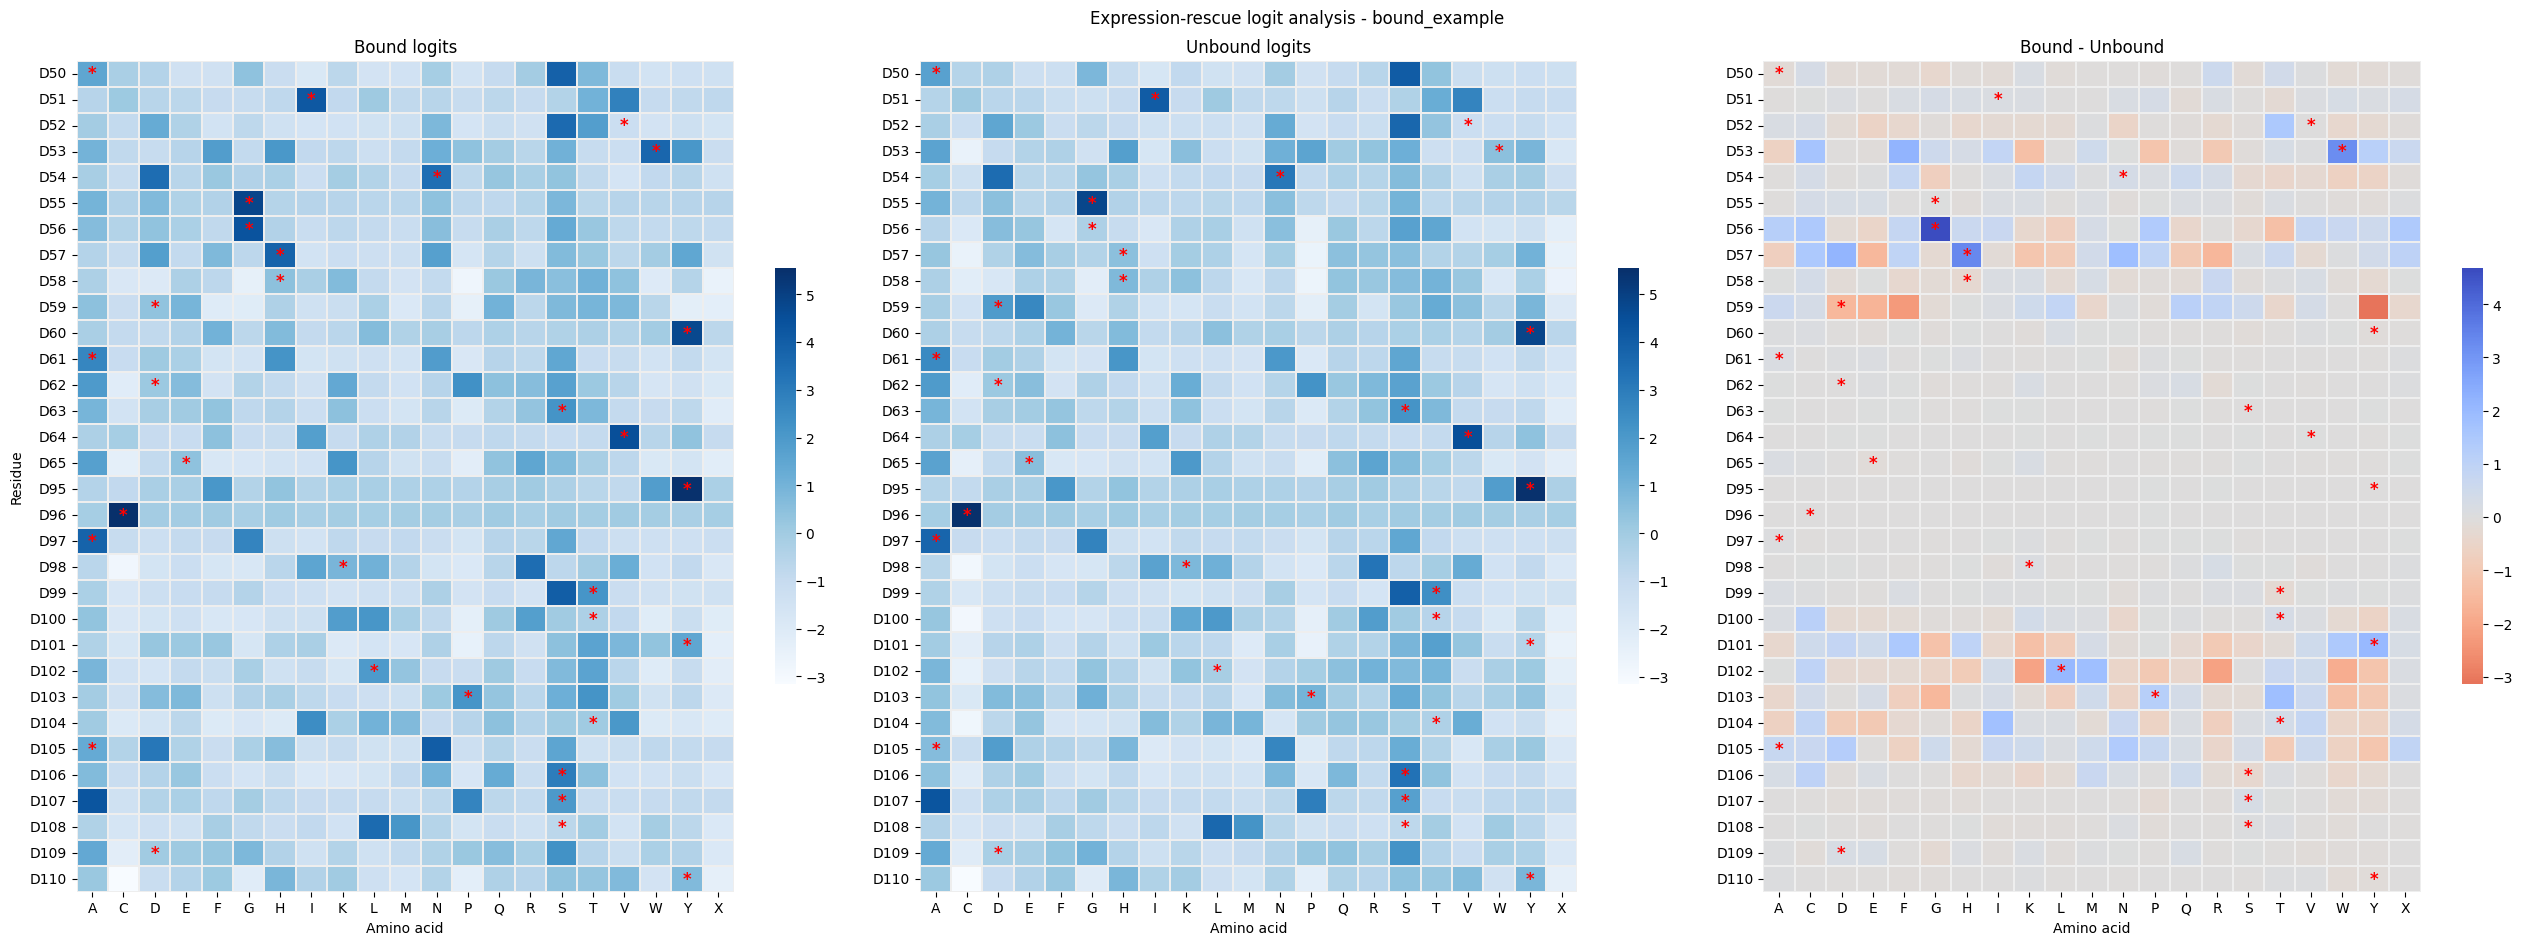

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(3 * 0.35 * n_aa + 4, max(6, 0.3 * n_res)))

# Color convention (consistent with the Step 8 3-D views): low = red, high = blue.
panels = [
    ("Bound logits", bound_mat, "Blues", None),
    ("Unbound logits", unbound_mat, "Blues", None),
    ("Bound - Unbound", diff_mat, "coolwarm_r", 0.0),
]

for ax, (title, mat, cmap, center) in zip(axes, panels):
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        center=center,
        xticklabels=alphabet,
        yticklabels=ordered_residues,
        cbar_kws={"shrink": 0.5},
        linewidths=0.2,
        linecolor="#eeeeee",
    )
    ax.set_title(title)
    ax.set_xlabel("Amino acid")
    ax.set_ylabel("Residue" if title == "Bound logits" else "")
    for i, wt in enumerate(wt_aas):
        j = aa_to_col[wt]
        ax.text(
            j + 0.5, i + 0.5, "*",
            ha="center", va="center",
            color="red", fontsize=12, fontweight="bold",
        )

fig.suptitle(f"Expression-rescue logit analysis - {stem}", fontsize=12)
fig.tight_layout()

heatmap_path = output_dir / "heatmap.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
print(f"Wrote {heatmap_path}")
plt.show()

## Step 8 - Logit-colored PDBs + inline viewer

Write two copies of the structure with the B-factor column replaced by the WT amino acid logit:

- `<stem>_logits.pdb` - bound complex, colored by **bound-state** logits
- `<stem>_unbound_logits.pdb` - antigen-removed copy, colored by **unbound-state** logits

Both are rendered inline with `py3Dmol` using a **red-white-blue** gradient. **Red = low logit** (WT is disfavored at that position — bad for folding/binding in that state); **blue = high logit** (WT is preferred). Residues outside the rescue set are shown in light gray for context.

The same files open in PyMOL with `spectrum b, red_white_blue` for a higher-fidelity view.

In [11]:
import matplotlib
import matplotlib.colors as mcolors
from IPython.display import display

def write_logit_pdb(src_pdb, dst_pdb, logits_dict, wt_map):
    """Copy src_pdb to dst_pdb with B-factor replaced by each residue's WT logit."""
    wt_logit_by_res = {
        res_name: float(aa_dict.get(wt_map.get(res_name), 0.0))
        for res_name, aa_dict in logits_dict.items()
        if wt_map.get(res_name) is not None
    }
    with open(src_pdb) as f_in, open(dst_pdb, "w") as f_out:
        for line in f_in:
            if line.startswith(("ATOM", "HETATM")):
                chain = line[21]
                resnum = line[22:26].strip()
                res_key = f"{chain}{resnum}"
                score = wt_logit_by_res.get(res_key, 0.0)
                # B-factor column is columns 61-66 (0-indexed 60:66), 6.2f.
                line = line[:60] + f"{score:6.2f}" + line[66:]
            f_out.write(line)
    return wt_logit_by_res

bound_logit_pdb = output_dir / f"{stem}_logits.pdb"
unbound_logit_pdb = output_dir / f"{stem}_unbound_logits.pdb"

bound_wt_logits = write_logit_pdb(
    bound_pdb_path, bound_logit_pdb, bound_logits, wt_bound,
)
unbound_wt_logits = write_logit_pdb(
    unbound_pdb_path, unbound_logit_pdb, unbound_logits, wt_unbound,
)

print(f"Wrote {bound_logit_pdb}")
print(f"Wrote {unbound_logit_pdb}")


# Color convention: low logit (WT not preferred) = red, high logit (WT preferred) = blue.
# 3Dmol.js gradient colorscheme can raise "s.range is not a function" on some builds,
# so we compute hex colors in matplotlib and set per-residue instead.
def render_logit_structure(pdb_path, wt_logit_by_res, vmin, vmax, cmap_name="bwr_r"):
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.colormaps[cmap_name]

    with open(pdb_path) as f:
        pdb_text = f.read()
    view = py3Dmol.view(width=500, height=400)
    view.addModel(pdb_text, "pdb")
    # Default every residue to light gray; specific residues get overridden below.
    view.setStyle({}, {"cartoon": {"color": "lightgray"}})
    for res_name, score in wt_logit_by_res.items():
        m = re.match(r"([A-Za-z]+)(\d+)", res_name)
        if not m:
            continue
        chain, resnum = m.group(1), m.group(2)
        hex_color = mcolors.to_hex(cmap(norm(score)))
        view.setStyle(
            {"chain": chain, "resi": resnum},
            {"cartoon": {"color": hex_color}},
        )
    view.zoomTo()
    return view

# Shared color scale across the two views so the panels are directly comparable.
all_scores = list(bound_wt_logits.values()) + list(unbound_wt_logits.values())
vmin, vmax = float(min(all_scores)), float(max(all_scores))
print(f"\nShared color scale: {vmin:.2f} (red, WT disfavored) -> {vmax:.2f} (blue, WT favored)")

print("\nBound:")
display(render_logit_structure(bound_logit_pdb, bound_wt_logits, vmin, vmax))

print("\nUnbound:")
display(render_logit_structure(unbound_logit_pdb, unbound_wt_logits, vmin, vmax))

print("\nHigher-fidelity view in PyMOL:")
print(f"  pymol {bound_logit_pdb} -d 'spectrum b, red_white_blue'")
print(f"  pymol {unbound_logit_pdb} -d 'spectrum b, red_white_blue'")

Wrote /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound_example_logits.pdb
Wrote /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound_example_unbound_logits.pdb

Shared color scale: -1.46 (red, WT disfavored) -> 6.09 (blue, WT favored)

Bound:


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Unbound:


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Higher-fidelity view in PyMOL:
  pymol /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound_example_logits.pdb -d 'spectrum b, red_white_blue'
  pymol /home/fullmoon/projects/Ab_MPNN/Ab_seq_design/expression_rescue_pipeline/output/bound_example_unbound_logits.pdb -d 'spectrum b, red_white_blue'


## Interpretation

- **High Δ rows on the bound panel** (dark blue cell with the red `*` WT marker) — the WT is preferred specifically because of the antigen contact. These are the **key-binding residues** flagged by Step 5; Step 6 excludes them from the rescue selection so the interface is not disturbed.
- **Blue cells in the difference panel** — amino acids the antigen *favors* at that position. Blue on the WT `*` column means the WT benefits from the antigen (binding residue).
- **Red cells in the difference panel** — amino acids the antigen *disfavors*. Red on a non-WT cell means the antigen pushes that AA down; red on the WT `*` means the antibody is paying a cost at that position.
- **Top of the Step 6 ranking (excluding key-binding)** — positions where the WT unbound logit is smallest *among non-binding residues*. In the paper we take the **top 3** and introduce the `best_aa` substitution at each.
- **3-D views in Step 8** — residues that are **blue in the bound view but red in the unbound view** are the strongest binding-driven stabilizations (key-binding residues; never targets for rescue). Residues that are **red in both views** are persistent rescue targets.

Outputs written to `output_dir`:

- `<stem>_unbound.pdb` - antigen-removed complex used for scoring
- `bound/<stem>.pt`, `unbound/<stem>.pt` - ProteinMPNN raw scores
- `key_binding_residues.csv` - all rescue residues with Δ column
- `rescue_ranking.csv` - all rescue residues ranked by WT unbound logit ascending; `is_key_binding` flags residues excluded from the top-K pick; `top_k=True` marks the selected mutations (non-binding residues only)
- `heatmap.png` - three-panel logit heatmap
- `<stem>_logits.pdb` - bound PDB with B-factor set to WT bound-logit
- `<stem>_unbound_logits.pdb` - unbound PDB with B-factor set to WT unbound-logit

Citations: Dauparas et al. 2022 (ProteinMPNN), 2025 (LigandMPNN).